# Preparación de datos WO₃ para PUMA

Procesa los archivos **ASC** (PerkinElmer UV WinLab) de transmitancia de WO₃ sobre cuarzo  
a diferentes flujos de oxígeno, elimina el rango corrupto 836–860 nm, interpola,  
aplica filtro Savitzky–Golay y genera los archivos PUMA (`FNAME-dat.txt`).

| Muestra | Flujo O₂ | Espesor estimado |
|---------|----------|------------------|
| S2      | 10 sccm  | 73.000 nm        |
| S5      |  7 sccm  | 105.145 nm       |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.signal import savgol_filter
from scipy.interpolate import PchipInterpolator, interp1d
import os

# ─── CONFIGURACIÓN GLOBAL ──────────────────────────────────────────────────────

SAMPLES = {
    "WO3_S2_10sccm": {
        "file"         : "WO3_datos_crudos/WO3_cuarzo_20260507_S2_10sccm_A.ASC",
        "thickness_nm" : 73.000,
        "label"        : "10 sccm – 73 nm",
        "color"        : "royalblue",
    },
    "WO3_S5_7sccm": {
        "file"         : "WO3_datos_crudos/WO3_cuarzo_20260507_S5_7sccm_A.ASC",
        "thickness_nm" : 105.145,
        "label"        : "7 sccm – 105.1 nm",
        "color"        : "darkorange",
    },
    "WO3_S8_5sccm": {
        "file"         : "WO3_datos_crudos/WO3_cuarzo_20260507_S8_5sccm_A.ASC",
        "thickness_nm" : 136.586,
        "label"        : "5 sccm – 136.6 nm",
        "color"        : "forestgreen",
    },
}

BAD_MIN = 836     # nm – inicio de zona corrupta
BAD_MAX = 860     # nm – fin de zona corrupta

# Rango para PUMA:
# - Límite inferior: 300 nm — incluye el borde de absorción del WO₃ (Eg ≈ 395–413 nm)
# - Límite superior: 1500 nm — máximo del modelo SUBSTRATE=60 en puma_mod.c
# El archivo dat se guarda con rango COMPLETO; PUMA recorta internamente con estos valores.
LAMBDA_MIN_PUMA = 300
LAMBDA_MAX_PUMA = 1500

# SUBSTRATE=60: cuarzo amorfo / fused silica (Malitson 1965, 3-term Sellmeier)
# Formula corregida en puma_mod.c — n≈1.46-1.49 en 300-1500 nm
SUBSTRATE    = 60
SG_WINDOW    = 61
SG_POLY      = 3
DIR_FILTRADO = "WO3_filtrado"
DIR_RESULTS  = "WO3_result_PUMA"

os.makedirs(DIR_FILTRADO, exist_ok=True)
os.makedirs(DIR_RESULTS,  exist_ok=True)
print("Configuración cargada.")
print(f"Sustrato: SUBSTRATE={SUBSTRATE} (cuarzo amorfo, Malitson 1965)")
print(f"Rango PUMA: {LAMBDA_MIN_PUMA}–{LAMBDA_MAX_PUMA} nm")
print(f"Carpeta de salida: {os.path.abspath(DIR_FILTRADO)}")

Configuración cargada.
Sustrato: SUBSTRATE=60 (cuarzo amorfo, Malitson 1965)
Rango PUMA: 300–1500 nm
Carpeta de salida: c:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_filtrado


## 1. Lectura de archivos ASC (PerkinElmer)

Formato: cabecera de metadata hasta `#DATA`, luego datos **tab-separados** con **coma decimal**:  
`2000,000000\t91,265012` → 6 decimales de precisión en T.

In [2]:
def read_wo3_asc(filepath):
    """
    Lee un archivo ASC de PerkinElmer UV WinLab.
    Busca '#DATA' y lee columnas tab-separadas con decimal de coma.
    Devuelve: wl (nm, ascendente), T (fracción 0-1).
    """
    wl_list, T_list = [], []
    in_data = False
    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            if line.strip() == "#DATA":
                in_data = True
                continue
            if not in_data:
                continue
            parts = line.strip().split("\t")
            if len(parts) != 2:
                continue
            try:
                lambda_nm = float(parts[0].replace(",", "."))
                T_pct     = float(parts[1].replace(",", "."))
                wl_list.append(lambda_nm)
                T_list.append(T_pct / 100.0)
            except ValueError:
                continue
    wl  = np.array(wl_list)
    T   = np.array(T_list)
    idx = np.argsort(wl)
    return wl[idx], T[idx]


raw_data = {}
for name, info in SAMPLES.items():
    wl, T = read_wo3_asc(info["file"])
    raw_data[name] = {"wl": wl, "T": T}
    print(f"{name}: {len(wl)} puntos | λ = {wl.min():.0f}–{wl.max():.0f} nm "
          f"| T máx = {T.max()*100:.4f}%  T mín = {T.min()*100:.4f}%")

WO3_S2_10sccm: 1751 puntos | λ = 250–2000 nm | T máx = 112.0812%  T mín = 7.0477%
WO3_S5_7sccm: 1751 puntos | λ = 250–2000 nm | T máx = 112.3270%  T mín = 1.8679%
WO3_S8_5sccm: 1751 puntos | λ = 250–2000 nm | T máx = 88.5980%  T mín = 1.6115%


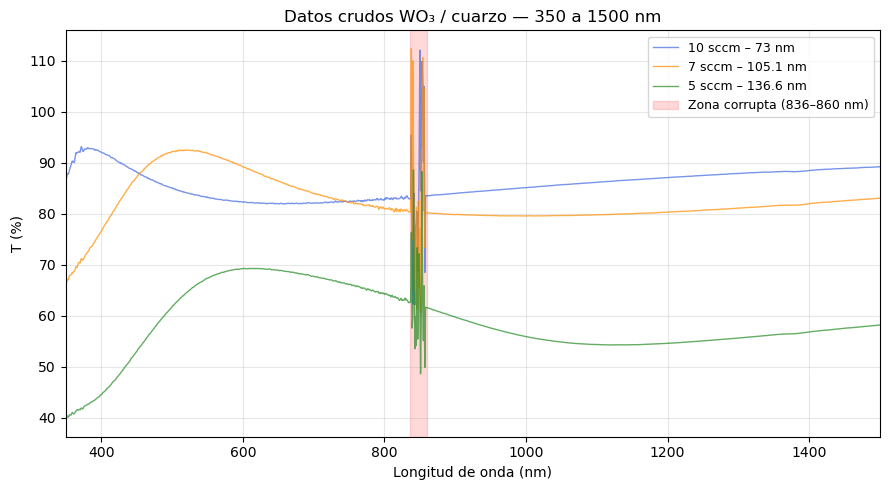

In [4]:
# Gráfica datos crudos – rango de trabajo
fig, ax = plt.subplots(figsize=(9, 5))

for name, info in SAMPLES.items():
    wl = raw_data[name]["wl"]
    T  = raw_data[name]["T"]
    m  = (wl >= 350) & (wl <= 1500)
    ax.plot(wl[m], T[m]*100, color=info["color"], alpha=0.7,
            linewidth=1, label=info["label"])

ax.axvspan(BAD_MIN, BAD_MAX, color="red", alpha=0.15,
           label=f"Zona corrupta ({BAD_MIN}–{BAD_MAX} nm)")
ax.set_xlabel("Longitud de onda (nm)")
ax.set_ylabel("T (%)")
ax.set_title("Datos crudos WO₃ / cuarzo — 350 a 1500 nm")
ax.set_xlim(350, 1500)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Eliminación de zona corrupta + Filtro S-G + Guardado

El archivo dat se guarda con el **rango completo (250–2000 nm)** — PUMA recorta internamente.

In [5]:
def remove_and_interpolate(wl, T):
    """Elimina zona corrupta e interpola con PCHIP usando vecinos ±100 nm."""
    mask_good  = (wl < BAD_MIN) | (wl > BAD_MAX)
    wl_good, T_good = wl[mask_good], T[mask_good]
    margin     = 100
    mask_local = (wl_good >= BAD_MIN - margin) & (wl_good <= BAD_MAX + margin)
    interp     = PchipInterpolator(wl_good[mask_local], T_good[mask_local])
    wl_gap     = np.arange(BAD_MIN, BAD_MAX + 1, 1.0)
    T_gap      = np.clip(interp(wl_gap), 0.0, 1.0)
    wl_out     = np.concatenate([wl_good, wl_gap])
    T_out      = np.concatenate([T_good,  T_gap])
    idx        = np.argsort(wl_out)
    return wl_out[idx], T_out[idx]


def save_puma_dat(wl, T, fname_base, output_dir):
    """Guarda rango completo en formato PUMA con notación científica."""
    T_clipped = np.clip(T, 0.0, 1.0)
    n_obs     = len(wl)
    outpath   = os.path.join(output_dir, f"{fname_base}-dat.txt")
    with open(outpath, "w") as f:
        f.write(f"{n_obs}\n")
        np.savetxt(f, np.column_stack([wl, T_clipped]), fmt="%.3e")
    size_kb = os.path.getsize(outpath) / 1024
    print(f"  ✓  {os.path.basename(outpath)}  |  {n_obs} puntos | "
          f"λ = {wl.min():.0f}–{wl.max():.0f} nm | {size_kb:.1f} kB")
    return outpath


clean_data    = {}
filtered_data = {}
puma_files    = {}

print(f"Procesando → {os.path.abspath(DIR_FILTRADO)}/\n")
for name, info in SAMPLES.items():
    wl_raw, T_raw = raw_data[name]["wl"], raw_data[name]["T"]
    wl_cl, T_cl   = remove_and_interpolate(wl_raw, T_raw)
    clean_data[name] = {"wl": wl_cl, "T": T_cl}
    T_sg = np.clip(savgol_filter(T_cl, window_length=SG_WINDOW, polyorder=SG_POLY), 0.0, 1.0)
    filtered_data[name] = {"wl": wl_cl, "T": T_sg}
    path = save_puma_dat(wl_cl, T_sg, name, DIR_FILTRADO)
    puma_files[name] = path

print("\nArchivos en WO3_filtrado/:")
for fname in sorted(os.listdir(DIR_FILTRADO)):
    if fname.endswith(".txt"):
        print(f"  {fname}")

primer = puma_files[list(SAMPLES.keys())[0]]
print(f"\nPrimeras 5 líneas de {os.path.basename(primer)}:")
with open(primer) as f:
    for i, line in enumerate(f):
        print(" ", line.rstrip())
        if i == 5: break

Procesando → c:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_filtrado/

  ✓  WO3_S2_10sccm-dat.txt  |  1751 puntos | λ = 250–2000 nm | 35.9 kB
  ✓  WO3_S5_7sccm-dat.txt  |  1751 puntos | λ = 250–2000 nm | 35.9 kB
  ✓  WO3_S8_5sccm-dat.txt  |  1751 puntos | λ = 250–2000 nm | 35.9 kB

Archivos en WO3_filtrado/:
  WO3_S2_10sccm-dat.txt
  WO3_S5_7sccm-dat.txt
  WO3_S8_5sccm-dat.txt

Primeras 5 líneas de WO3_S2_10sccm-dat.txt:
  1751
  2.500e+02 7.330e-02
  2.510e+02 7.427e-02
  2.520e+02 7.539e-02
  2.530e+02 7.668e-02
  2.540e+02 7.812e-02


## 3. Comparación: crudo vs filtrado

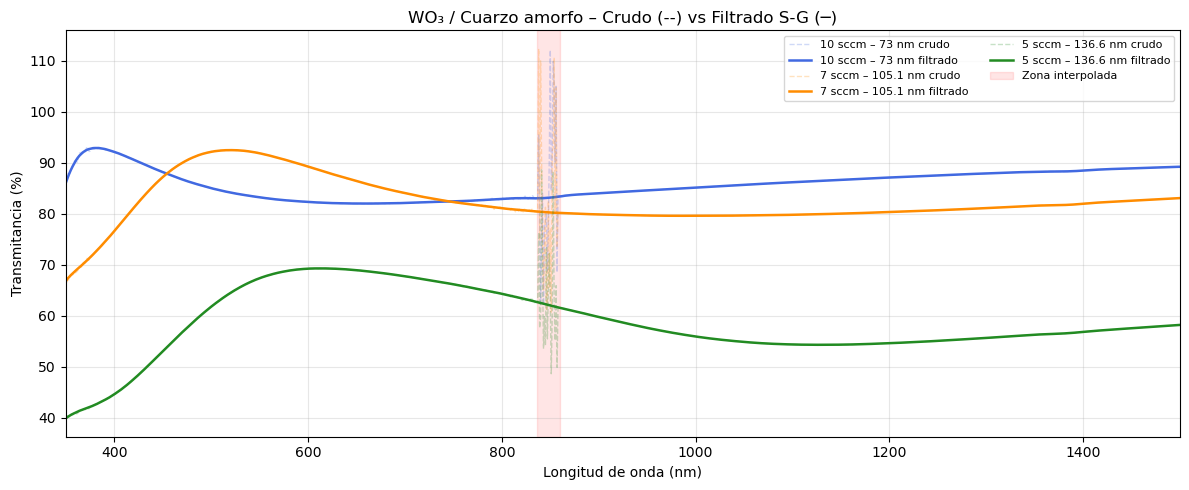

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, info in SAMPLES.items():
    wl_r = raw_data[name]["wl"]
    T_r  = raw_data[name]["T"]
    wl_f = filtered_data[name]["wl"]
    T_f  = filtered_data[name]["T"]
    mr   = (wl_r >= 350) & (wl_r <= 1500)
    mf   = (wl_f >= 350) & (wl_f <= 1500)
    ax.plot(wl_r[mr], T_r[mr]*100, color=info["color"], alpha=0.25, linewidth=1,
            linestyle="--", label=f"{info['label']} crudo")
    ax.plot(wl_f[mf], T_f[mf]*100, color=info["color"], alpha=1.0, linewidth=1.8,
            label=f"{info['label']} filtrado")
ax.axvspan(BAD_MIN, BAD_MAX, color="red", alpha=0.10, label="Zona interpolada")
ax.set_xlabel("Longitud de onda (nm)")
ax.set_ylabel("Transmitancia (%)")
ax.set_title("WO₃ / Cuarzo amorfo – Crudo (--) vs Filtrado S-G (─)")
ax.set_xlim(350, 1500)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Estrategia de runs PUMA

Cada run refina al anterior usando `INIT=9` (parte del `-sol.txt` previo).
Parámetros comunes: `NLAYERS=4`, `SLAYER=2`, `SUBSTRATE=60` (cuarzo amorfo, Malitson 1965), `LMIN=300 nm`, `LMAX=1500 nm`.

| Run | INIT | maxIT | Espesor | Inflexión | NOBS | Propósito |
|-----|------|-------|---------|-----------|------|-----------|
| 1 | 0 | 3 000 | ±20%, paso 5 nm | 340–460, paso 20 | 175 | Barrido amplio |
| 2 | 9 | 5 000 | ±7%, paso 1 nm | 340–460, paso 20 | 175 | Refinamiento |
| 3 | 9 | 50 000 | fijo (d_run2) | fija (inf_run2) | 100/125/175 | Ajuste fino |

> **Nota:** los runs P1–P6 usaron `LMIN=350 nm`, cortando el borde de absorción del WO₃ (Eg ≈ 2.9–3.1 eV). Archivados en `WO3_result_PUMA/S*/pruebas/`.

## Tabla de parámetros – First Call (referencia)

| Parámetro | Valor | Significado |
|-----------|-------|-------------|
| `NLAYERS` | 4 | aire / WO₃ / cuarzo / aire |
| `SLAYER` | 2 | capa sustrato = cuarzo |
| `SUBSTRATE` | **60** | cuarzo amorfo / fused silica — Malitson 1965 (corregido en `puma_mod.c`) |
| `DATATYPE` | T | transmitancia |
| `NOBS` | 100 | puntos equiespaciados para el ajuste |
| `LAMBDAmin` | 300 nm | por debajo WO₃ absorbe fuerte (T < 10%) |
| `LAMBDAmax` | 1500 nm | límite del modelo de cuarzo en PUMA |
| `maxIT` | 3000 | balance entre convergencia y tiempo de cluster |
| `QUAD` | 1e+100 | sin cota de error (first call) |
| `INIT` | 0 | estimación inicial desde cero |
| `THICKNESSstep` | 2 nm | paso grueso para first call |
| `INFLEstep` | 100 nm | exploración gruesa del punto de inflexión |
| `N0ini/fin` | 1.90 / 2.50 | n en λ_min; extendido a 1.90 (±15% sobre n≈2.2) |
| `NFini/fin` | 1.80 / 2.20 | n en λ_max — WO₃ literatura |
| `N0/NFstep` | 0.10 | **paso grueso** (vs 0.05 del ITO) |
| `K0ini/fin` | 0.25 / 0.55 | k≈0.45 en 300 nm (Fig. 4.3a) ±15%; k→0 en 1500 nm |
| `K0step` | 0.05 | 7 valores: 0.25, 0.30, …, 0.55 |

> **Antes de lanzar:** recompilar `puma_mod.c` en el cluster con `gcc -O4 -lm puma_mod.c -o puma_mod`  
> **Después del first call:** revisar `FNAME-inf.txt`, anotar espesor, inflexión y error cuadrático,  
> y afinar con second call (`INIT=9`, paso más fino, `maxIT=5000`)

## 5. Resultados PUMA – Análisis de `-inf.txt`

Copia los archivos `*-inf.txt` del cluster a la carpeta `WO3_result_PUMA/` antes de correr esta sección.

Para cada muestra se extraen:
- **n(λ)** y **k(λ)** de la sección `REFRACTIVE INDICES AND ABSORPTION`
- **T simulada** de la sección `TRANSMITTANCE WITH THE ESTIMATED`

y se comparan contra los datos experimentales filtrados en el mismo rango que la simulación.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.signal import savgol_filter
from scipy.interpolate import PchipInterpolator, interp1d
import os
import glob

# ── CARGAR RESULTADOS PUMA ─────────────────────────────────────────────────────
SAMPLES_RESULTS = {
    "WO3_S2_10sccm": os.path.join(DIR_RESULTS, "S2"),
    "WO3_S5_7sccm" : os.path.join(DIR_RESULTS, "S5"),
}

def parse_puma_inf(filepath):
    """
    Lee un archivo PUMA *-inf.txt y extrae n(λ), k(λ), T_sim(λ),
    espesor, inflexión y QE.
    """
    if not os.path.exists(filepath):
        return None

    block_nk, block_t = [], []
    section   = None
    thickness = inflexion = qe = None

    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            ls = line.strip()
            if "Thickness of film 1" in ls:
                try: thickness = float(ls.split("=")[-1].strip().split()[0])
                except: pass
            if "Inflexion point" in ls:
                try: inflexion = float(ls.split("=")[-1].strip().split()[0])
                except: pass
            if "QUADRATIC ERROR" in ls:
                try: qe = float(ls.split("=")[-1].strip())
                except: pass
            if "REFRACTIVE INDICES AND ABSORPTION" in ls:
                section = "nk"; continue
            if "TRANSMITTANCE WITH THE ESTIMATED" in ls:
                section = "t"; continue
            if not ls or ls.startswith("lambda") or ls.startswith("Film"):
                continue
            try:
                vals = list(map(float, ls.split()))
                if section == "nk" and len(vals) == 3:
                    block_nk.append(vals)
                elif section == "t" and len(vals) == 2:
                    block_t.append(vals)
            except ValueError:
                continue

    if not block_nk or not block_t:
        print(f" {os.path.basename(filepath)}: secciones incompletas")
        return None

    nk = np.array(block_nk)
    t  = np.array(block_t)
    return {
        "wl_nk": nk[:,0], "n": nk[:,1], "k": nk[:,2],
        "wl_t" : t[:,0],  "T_sim": t[:,1],
        "thickness": thickness, "inflexion": inflexion,
        "qe": qe, "filepath": filepath,
    }


def escanear_resultados(sample, folder):
    """
    Busca archivos con patrón {sample}-inf_run*.
    Extrae etiqueta run (ej. 'run1_175', 'run3_100').
    Excluye subcarpeta pruebas/.
    """
    patron  = os.path.join(folder, f"{sample}-inf_run*")
    archivos = sorted(glob.glob(patron))

    resultados = {}
    for fp in archivos:
        if "pruebas" in fp:
            continue
        etiqueta = os.path.basename(fp).replace(f"{sample}-inf_", "")
        res = parse_puma_inf(fp)
        if res is not None:
            resultados[etiqueta] = res
    return resultados


# ── CARGAR ────────────────────────────────────────────────────────────────────
print("Escaneando resultados PUMA...\n")
puma_results = {}

for sample, folder in SAMPLES_RESULTS.items():
    pruebas = escanear_resultados(sample, folder)
    if not pruebas:
        print(f"  –  {sample}: sin archivos en {folder}/")
        continue
    puma_results[sample] = pruebas
    print(f"  {sample}:")
    for etiqueta, res in pruebas.items():
        d   = f"{res['thickness']:.1f} nm" if res['thickness'] else "?"
        inf = f"{res['inflexion']:.0f} nm" if res['inflexion'] else "?"
        qe  = f"{res['qe']:.2e}"           if res['qe']       else "?"
        print(f"    [{etiqueta}]  d={d}  inflexión={inf}  QE={qe}")

print(f"\nTotal muestras cargadas: {len(puma_results)}")

Escaneando resultados PUMA...

  WO3_S2_10sccm:
    [run1_175]  d=95.0 nm  inflexión=350 nm  QE=4.00e-05
    [run2_125]  d=95.0 nm  inflexión=350 nm  QE=2.90e-05
    [run2_175]  d=95.0 nm  inflexión=350 nm  QE=1.04e-05
    [run3_100]  d=95.0 nm  inflexión=350 nm  QE=2.65e-05
    [run3_125]  d=95.0 nm  inflexión=350 nm  QE=2.90e-05
    [run3_150]  d=95.0 nm  inflexión=350 nm  QE=8.76e-06
    [run3_175]  d=95.0 nm  inflexión=350 nm  QE=1.04e-05
    [run3_nobs100_250-800]  d=95.0 nm  inflexión=275 nm  QE=6.28e-05
    [run3_nobs150_250-800]  d=95.0 nm  inflexión=300 nm  QE=9.10e-05
  WO3_S5_7sccm:
    [run1_125]  d=130.0 nm  inflexión=350 nm  QE=7.29e-05
    [run1_175]  d=130.0 nm  inflexión=350 nm  QE=1.01e-04
    [run1_nuevo]  d=130.0 nm  inflexión=280 nm  QE=5.51e-05
    [run2_175]  d=131.0 nm  inflexión=350 nm  QE=8.26e-05
    [run3_100]  d=131.0 nm  inflexión=330 nm  QE=5.03e-05
    [run3_125]  d=131.0 nm  inflexión=350 nm  QE=5.87e-05
    [run3_150]  d=131.0 nm  inflexión=350 nm  QE=

In [4]:
# ── CONFIGURACIÓN ─────────────────────────────────────────────────────────────
hc_eV_nm = 1239.84  # eV·nm

SAMPLE_INFO = {
    "WO3_S2_10sccm": {"color": "steelblue",  "label": "S2 — 10 sccm O₂"},
    "WO3_S5_7sccm" : {"color": "darkorange", "label": "S5 — 7 sccm O₂"},
}

EXP_FILES = {
    "WO3_S2_10sccm": os.path.join(DIR_FILTRADO, "WO3_S2_10sccm-dat.txt"),
    "WO3_S5_7sccm" : os.path.join(DIR_FILTRADO, "WO3_S5_7sccm-dat.txt"),
}

# Selección de runs a graficar — [] = todos los disponibles para esa muestra
GRAFICAR = {
    "WO3_S2_10sccm": ["run3_100", "run3_125", "run3_150", "run3_175"],
    "WO3_S5_7sccm" : ["run3_100", "run3_125", "run3_150", "run3_175"],
}

# Estilos de línea por etiqueta run3
NOBS_STYLES = {
    "run3_100": (":",  0.8),
    "run3_125": ("--", 1.2),
    "run3_150": ("-.", 1.5),
    "run3_175": ("-",  2.0),
}

# ── FILTRAR ────────────────────────────────────────────────────────────────────
resultados_plot = {}
for sample, runs_sel in GRAFICAR.items():
    if sample not in puma_results:
        print(f"  ? {sample} no encontrado en puma_results")
        continue
    filtradas = {e: r for e, r in puma_results[sample].items()
                 if not runs_sel or e in runs_sel}
    if filtradas:
        resultados_plot[sample] = filtradas
    else:
        print(f"  ? {sample}: ninguno de {runs_sel} encontrado "
              f"(disponibles: {list(puma_results[sample].keys())})")

# ── CARGAR EXPERIMENTALES ──────────────────────────────────────────────────────
filtered_data = {}
for sample, path in EXP_FILES.items():
    if os.path.exists(path):
        d = np.loadtxt(path, skiprows=1)
        filtered_data[sample] = {"wl": d[:, 0], "T": d[:, 1]}
    else:
        print(f"  ? Experimental no encontrado: {path}")

In [5]:
# ── FUNCIONES DE GRAFICACIÓN ──────────────────────────────────────────────────
# Runs finales seleccionados por muestra
MEJOR_RUN = {
    "WO3_S2_10sccm": "run3_150",  # menor error numérico
    "WO3_S5_7sccm" : "run3_175",  # más físicamente consistente
}

def mejor_run3(sample):
    return MEJOR_RUN.get(sample, None)

def plot_nk(ax_n, ax_k, sample, etiqueta, res, info, ls="-", lw=2.0, label=None):
    lbl = label or info["label"]
    ax_n.plot(res["wl_nk"], res["n"],
              color=info["color"], linewidth=lw, linestyle=ls, label=lbl)
    k = res["k"].copy()
    k_valid = k[k > 1e-8]
    if len(k_valid) == 0:
        # k indetectable — graficar línea fantasma solo para que aparezca en leyenda
        ax_k.plot([], [], color=info["color"], linewidth=lw,
                  linestyle=ls, label=f"{lbl} (k ≈ 0)")
    else:
        k[k < 1e-8] = np.nan
        ax_k.plot(res["wl_nk"], k,
                  color=info["color"], linewidth=lw, linestyle=ls, label=lbl)

def plot_n_only(ax, sample, etiqueta, res, info, ls="-", lw=2.0, label=None):
    lbl = label or info["label"]
    ax.plot(res["wl_nk"], res["n"],
            color=info["color"], linewidth=lw, linestyle=ls, label=lbl)

def plot_T(ax, sample, etiqueta, res, info):
    lam_lo, lam_hi = res["wl_t"].min(), res["wl_t"].max()
    if sample in filtered_data:
        wl_exp = filtered_data[sample]["wl"]
        T_exp  = filtered_data[sample]["T"]
        mask   = (wl_exp >= lam_lo) & (wl_exp <= lam_hi)
        wl_exp, T_exp = wl_exp[mask], T_exp[mask]
        T_sim_i = interp1d(res["wl_t"], res["T_sim"],
                           kind="linear", bounds_error=False,
                           fill_value="extrapolate")(wl_exp)
        rmse = np.sqrt(np.mean((T_sim_i - T_exp)**2))
        mape = np.mean(np.abs(T_sim_i - T_exp) / np.clip(T_exp, 1e-6, None)) * 100
        ax.plot(wl_exp, T_exp*100, color=info["color"],
                linewidth=1.5, alpha=0.7, label="Experimental")
        subtitulo = (f"{info['label']}  |  d = {res['thickness']:.0f} nm  "
                     f"RMSE = {rmse*100:.3f}%  MAPE = {mape:.2f}%")
    else:
        subtitulo = f"{info['label']}  |  d = {res['thickness']:.0f} nm"
    ax.plot(res["wl_t"], res["T_sim"]*100, color="black",
            linewidth=2, linestyle="--", label="PUMA simulada")
    ax.set_xlabel("λ (nm)", fontsize=12)
    ax.set_ylabel("T (%)", fontsize=12)
    ax.set_title(subtitulo, fontsize=10)
    ax.set_xlim(lam_lo, lam_hi)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

def setup_nk_axes(ax_n, ax_k):
    ax_n.set_xlabel("λ (nm)", fontsize=12)
    ax_n.set_ylabel("n", fontsize=12)
    ax_n.set_xlim(LAMBDA_MIN_PUMA, LAMBDA_MAX_PUMA)
    ax_n.legend(fontsize=10)
    ax_n.grid(True, alpha=0.3)
    ax_k.set_xlabel("λ (nm)", fontsize=12)
    ax_k.set_ylabel("k", fontsize=12)
    ax_k.set_yscale("log")
    ax_k.set_xlim(LAMBDA_MIN_PUMA, LAMBDA_MAX_PUMA)
    ax_k.legend(fontsize=10)
    ax_k.grid(True, alpha=0.3, which="both")

def setup_n_axis(ax):
    ax.set_xlabel("λ (nm)", fontsize=12)
    ax.set_ylabel("n", fontsize=12)
    ax.set_xlim(LAMBDA_MIN_PUMA, LAMBDA_MAX_PUMA)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

def tauc_plot(ax, resultados_plot, SAMPLE_INFO, hc_eV_nm, potencia, ylabel):
    hnu_min_all, hnu_max_all = np.inf, -np.inf

    EG_RANGES = {
        "WO3_S2_10sccm": (2.25, 3.50),
        "WO3_S5_7sccm" : (2.25, 3.50),
    }

    for sample, pruebas in resultados_plot.items():
        info = SAMPLE_INFO.get(sample, {"color": "gray", "label": sample})
        for etiqueta, res in pruebas.items():
            wl = res["wl_nk"]
            k  = res["k"]

            mask_all = k > 1e-8
            if not mask_all.any():
                print(f"  {info['label']} [{etiqueta}]: k ≈ 0 — omitido del Tauc")
                continue

            wl_all    = wl[mask_all]
            k_all     = k[mask_all]
            hnu_all   = hc_eV_nm / wl_all
            alpha_all = 4 * np.pi * k_all / (wl_all * 1e-7)
            tauc_all  = (alpha_all * hnu_all) ** potencia

            idx      = np.argsort(hnu_all)
            hnu_all  = hnu_all[idx]
            tauc_all = tauc_all[idx]

            hnu_min_all = min(hnu_min_all, hnu_all.min())
            hnu_max_all = max(hnu_max_all, hnu_all.max())

            label = f"{info['label']} [{etiqueta}]" if len(pruebas) > 1 else info["label"]
            ax.plot(hnu_all, tauc_all, color=info["color"],
                    linewidth=2.0, linestyle="-", label=label)

            # ── Ajuste lineal en rango manual ─────────────────────────────────
            mask_lin = k[mask_all][idx] > 1e-6
            hnu_lin  = hnu_all[mask_lin]
            tauc_lin = tauc_all[mask_lin]
            if not mask_lin.any():
                continue

            rango    = EG_RANGES.get(sample, (2.25, 3.50))
            lin_mask = (hnu_lin >= rango[0]) & (hnu_lin <= rango[1])

            if lin_mask.sum() < 3:
                print(f"  {info['label']} [{etiqueta}]: sin puntos en "
                      f"rango {rango} — omitido")
                continue

            coeffs = np.polyfit(hnu_lin[lin_mask], tauc_lin[lin_mask], 1)
            poly   = np.poly1d(coeffs)
            Eg     = -coeffs[1] / coeffs[0]

            if not (0.5 < Eg < 5.0):
                print(f"  {info['label']} [{etiqueta}]: "
                      f"Eg fuera de rango ({Eg:.2f} eV) — omitido")
                continue

            hnu_line = np.linspace(Eg, hnu_lin[lin_mask].max(), 100)
            ax.plot(hnu_line, poly(hnu_line), color=info["color"],
                    linewidth=1.8, linestyle="-", alpha=0.85)
            ax.plot(Eg, 0, "o", color=info["color"], markersize=7, zorder=5)
            ax.axvline(Eg, color=info["color"], linewidth=1.0,
                       linestyle=":", alpha=0.6)
            ax.text(Eg + 0.03, tauc_lin.max() * 0.90,
                    f"$E_g$ = {Eg:.2f} eV",
                    fontsize=11, color=info["color"], va="top", ha="left",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                              edgecolor=info["color"], alpha=0.7))
            tipo = "indirecto" if potencia == 0.5 else "directo"
            print(f"  [{tipo}] {info['label']} [{etiqueta}]: "
                  f"Eg = {Eg:.2f} eV  ({hc_eV_nm/Eg:.0f} nm)")

    if np.isfinite(hnu_min_all) and np.isfinite(hnu_max_all):
        margen = (hnu_max_all - hnu_min_all) * 0.08
        ax.set_xlim(hnu_min_all - margen * 2, hnu_max_all + margen)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_xlabel(r"$h\nu$ (eV)", fontsize=13)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

Guardado: Imagenes/n_S2vsS5.pdf
Guardado: Imagenes/n_S2vsS5.png
Guardado: Imagenes/k_S2vsS5.pdf
Guardado: Imagenes/k_S2vsS5.png


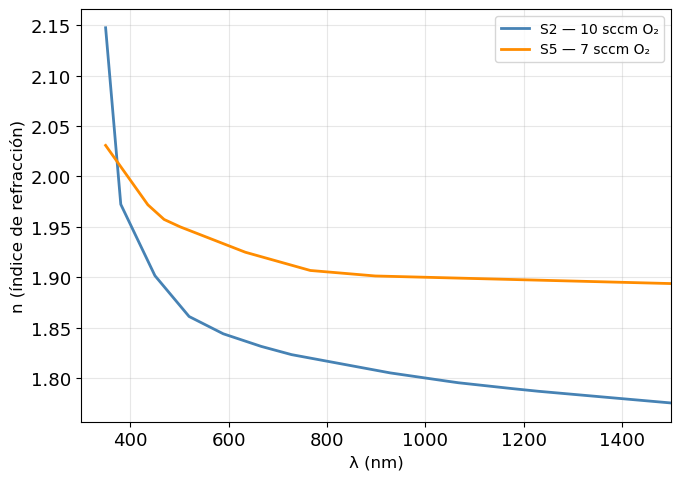

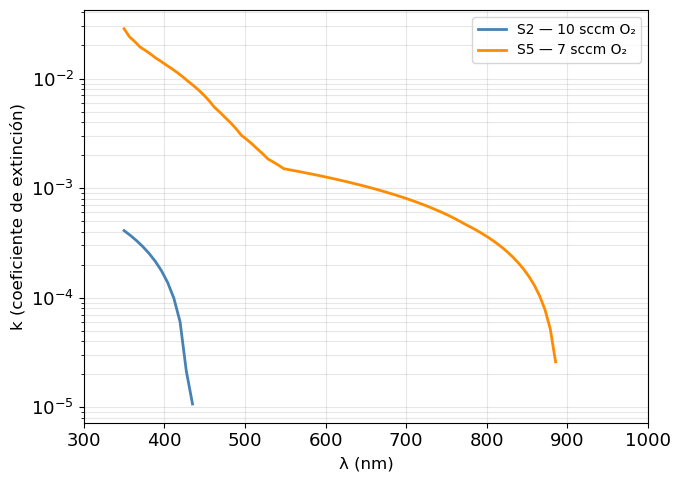

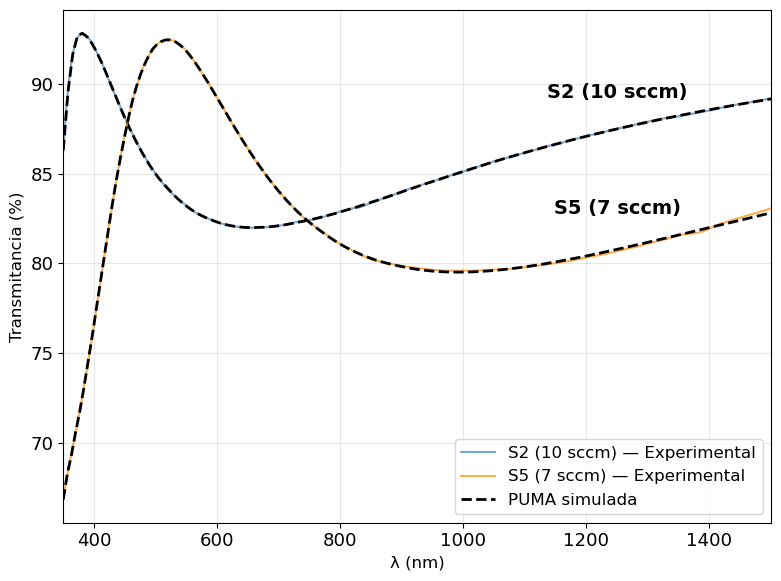

Guardado: Imagenes/T_S2vsS5_superpuesta.pdf
Guardado: Imagenes/T_S2vsS5_superpuesta.png


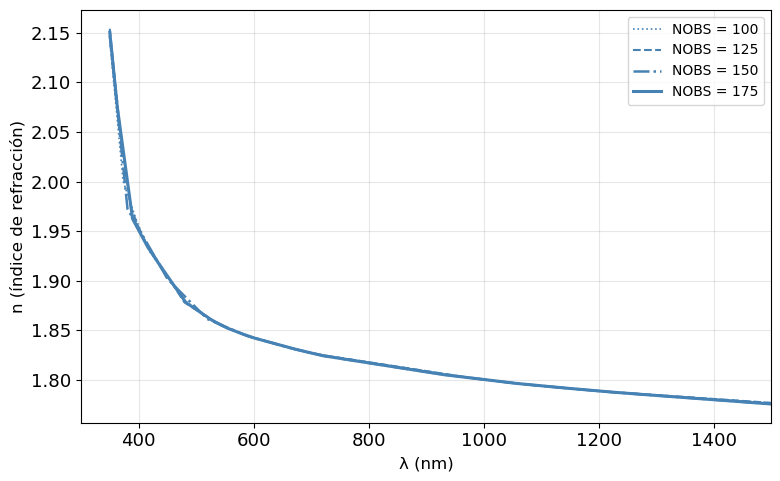

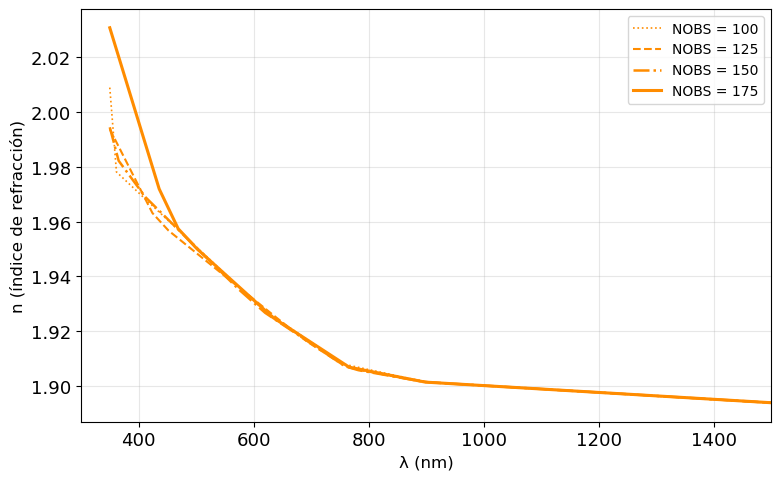

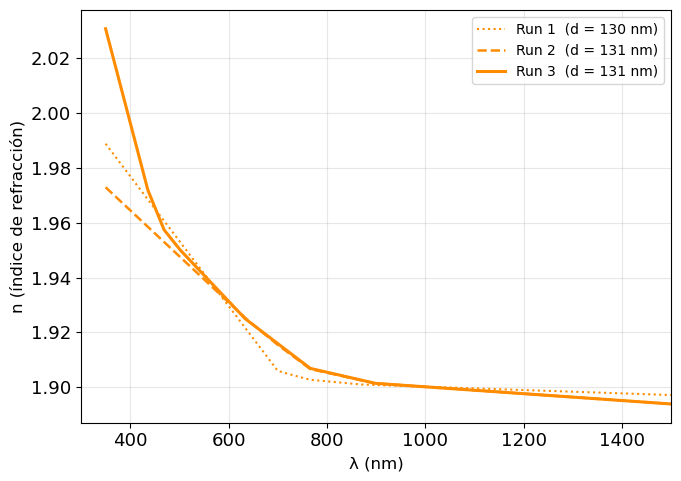

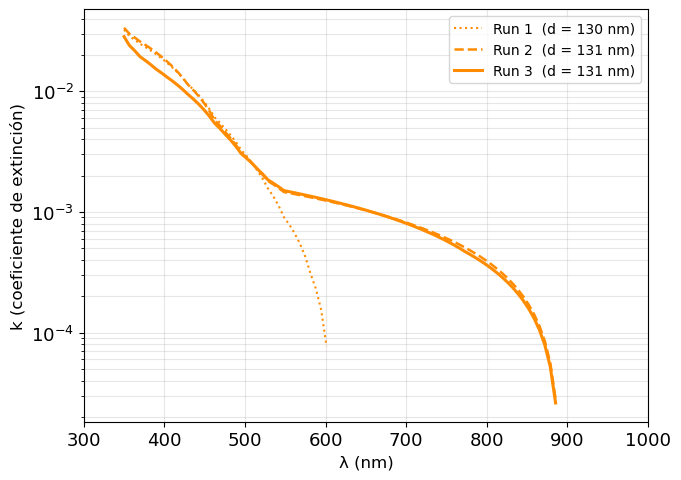

In [8]:
# ── GRÁFICAS ──────────────────────────────────────────────────────────────────
# Tamaño de letra global (mismo criterio usado en las gráficas de comparación
# PUMA vs SPG): etiquetas de eje 15, ticks 13, leyenda 12.
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
})

NOBS_STYLES = {
    "run3_100": (":",  1.2),
    "run3_125": ("--", 1.5),
    "run3_150": ("-.", 1.8),
    "run3_175": ("-",  2.2),
}

run_S2 = mejor_run3("WO3_S2_10sccm")
run_S5 = mejor_run3("WO3_S5_7sccm")

# ── 1. n(λ) — S2 vs S5 (figura separada) ─────────────────────────────────────
fig_n, ax_n = plt.subplots(figsize=(7, 5))
fig_k, ax_k = plt.subplots(figsize=(7, 5))
for sample, run in [("WO3_S2_10sccm", run_S2), ("WO3_S5_7sccm", run_S5)]:
    if run is None: continue
    plot_nk(ax_n, ax_k, sample, run,
            resultados_plot[sample][run], SAMPLE_INFO[sample])
setup_nk_axes(ax_n, ax_k)
ax_n.set_title("")
ax_k.set_title("")
ax_n.set_ylabel("n (índice de refracción)")
ax_k.set_ylabel("k (coeficiente de extinción)")
ax_k.set_xlim(ax_k.get_xlim()[0], 1000)

fig_n.tight_layout()
fig_n.savefig(os.path.join("Imagenes", "n_S2vsS5.pdf"), bbox_inches="tight", dpi=300)
fig_n.savefig(os.path.join("Imagenes", "n_S2vsS5.png"), bbox_inches="tight", dpi=300)
print("Guardado: Imagenes/n_S2vsS5.pdf")
print("Guardado: Imagenes/n_S2vsS5.png")

fig_k.tight_layout()
fig_k.savefig(os.path.join("Imagenes", "k_S2vsS5.pdf"), bbox_inches="tight", dpi=300)
fig_k.savefig(os.path.join("Imagenes", "k_S2vsS5.png"), bbox_inches="tight", dpi=300)
print("Guardado: Imagenes/k_S2vsS5.pdf")
print("Guardado: Imagenes/k_S2vsS5.png")

plt.show()

# ── 2. T experimental vs simulada — S2 y S5 superpuestas en un solo eje ──────
fig, ax = plt.subplots(figsize=(8, 6))
for sample, run in [("WO3_S2_10sccm", run_S2), ("WO3_S5_7sccm", run_S5)]:
    if run is None: continue
    plot_T(ax, sample, run,
           resultados_plot[sample][run], SAMPLE_INFO[sample])
ax.set_title("")
ax.set_ylabel("Transmitancia (%)")
ax.set_xlabel("λ (nm)")

# plot_T no distingue S2 de S5 en la leyenda (ambas llamadas agregan
# "Experimental" y "PUMA simulada" sin identificar la muestra), asi que
# reconstruimos la leyenda con etiquetas explicitas. El orden de las 4
# lineas generadas es [Exp_S2, Sim_S2, Exp_S5, Sim_S5].
#
# Las dos lineas "PUMA simulada" (S2 y S5) se ven identicas en el grafico
# (negro punteado), asi que en vez de repetir la etiqueta dos veces se deja
# una sola entrada generica "PUMA simulada" en la leyenda. La linea Sim_S5
# se sigue dibujando en el grafico, solo que sin su propia entrada en la
# leyenda (queda representada por la misma entrada que Sim_S2).
handles, _ = ax.get_legend_handles_labels()
handles_legend = [handles[0], handles[2], handles[1]]
etiquetas_legend = [
    "S2 (10 sccm) — Experimental",
    "S5 (7 sccm) — Experimental",
    "PUMA simulada",
]
ax.legend(handles_legend, etiquetas_legend, loc="lower right")

# Etiquetas directas sobre cada curva (ademas de la leyenda), como pidio el
# profesor. Coordenadas aproximadas segun donde el ajusto puso el texto a
# mano -- revisar al correrlo y mover si no calzan bien con tus datos reales.
ax.text(1250, 89, "S2 (10 sccm)", fontsize=14, fontweight="bold",
        color="black", ha="center", va="bottom")
ax.text(1250, 82.5, "S5 (7 sccm)", fontsize=14, fontweight="bold",
        color="black", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(os.path.join("Imagenes", "T_S2vsS5_superpuesta.pdf"), bbox_inches="tight", dpi=300)
plt.savefig(os.path.join("Imagenes", "T_S2vsS5_superpuesta.png"), bbox_inches="tight", dpi=300)
plt.show()
print("Guardado: Imagenes/T_S2vsS5_superpuesta.pdf")
print("Guardado: Imagenes/T_S2vsS5_superpuesta.png")

# ── 3. Convergencia NOBS en run3 — solo n(λ) ─────────────────────────────────
for sample in ["WO3_S2_10sccm", "WO3_S5_7sccm"]:
    info  = SAMPLE_INFO[sample]
    runs3 = sorted([e for e in resultados_plot.get(sample, {})
                    if e.startswith("run3_")],
                   key=lambda e: int(e.split("_")[-1]))
    if not runs3: continue
    fig, ax = plt.subplots(figsize=(8, 5))
    for etiqueta in runs3:
        res    = resultados_plot[sample][etiqueta]
        ls, lw = NOBS_STYLES.get(etiqueta, ("-", 1.5))
        nobs   = etiqueta.split("_")[-1]
        plot_n_only(ax, sample, etiqueta, res, info,
                    ls=ls, lw=lw, label=f"NOBS = {nobs}")
    setup_n_axis(ax)
    ax.set_title("")
    ax.set_ylabel("n (índice de refracción)")
    plt.tight_layout()
    plt.show()

# ── 4. Cadena completa S5: run1_175 → run2_175 → run3_175 (n y k separados) ──
sample_cadena = "WO3_S5_7sccm"
cadena_runs   = ["run1_175", "run2_175", "run3_175"]
cadena_styles = {
    "run1_175": (":",  1.5),
    "run2_175": ("--", 1.8),
    "run3_175": ("-",  2.2),
}
disponibles = {e: puma_results[sample_cadena][e]
               for e in cadena_runs
               if e in puma_results.get(sample_cadena, {})}

if disponibles:
    info = SAMPLE_INFO[sample_cadena]
    fig_n, ax_n = plt.subplots(figsize=(7, 5))
    fig_k, ax_k = plt.subplots(figsize=(7, 5))
    for etiqueta, res in disponibles.items():
        ls, lw    = cadena_styles[etiqueta]
        run_label = etiqueta.replace("_175", "").replace("run", "Run ")
        plot_nk(ax_n, ax_k, sample_cadena, etiqueta, res, info,
                ls=ls, lw=lw,
                label=f"{run_label}  (d = {res['thickness']:.0f} nm)")
    setup_nk_axes(ax_n, ax_k)
    ax_n.set_title("")
    ax_k.set_title("")
    ax_n.set_ylabel("n (índice de refracción)")
    ax_k.set_ylabel("k (coeficiente de extinción)")
    ax_k.set_xlim(ax_k.get_xlim()[0], 1000)

    fig_n.tight_layout()
    fig_k.tight_layout()
    plt.show()
else:
    print(f"Faltan runs: {list(puma_results.get(sample_cadena, {}).keys())}")

S2: d=95.0 nm | inf=300.0 nm | error=9.102e-05
S5: d=131.0 nm | inf=280.0 nm | error=3.612e-05
S2: Eg = 3.395 eV | R² = 0.9994 | rango [3.27-4.21] eV
S5: Eg = 3.340 eV | R² = 0.9983 | rango [3.15-3.55] eV


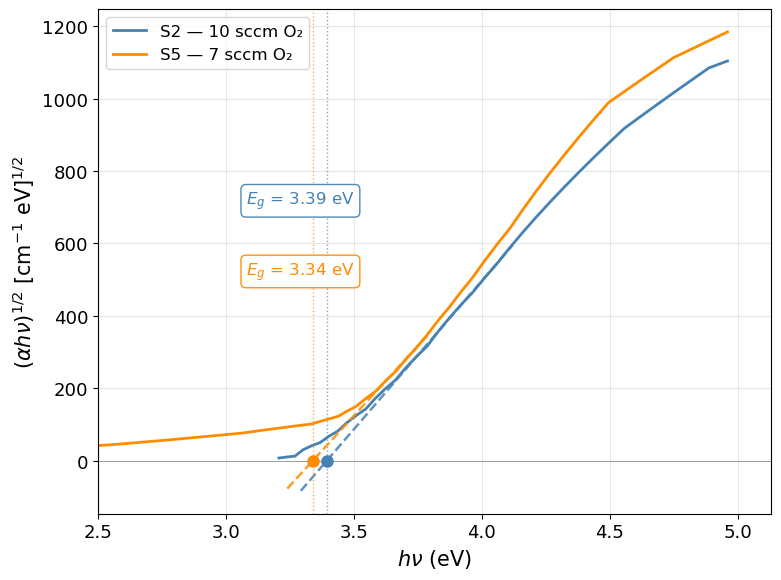

Guardado: C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_result_PUMA\tauc_UV_S2vsS5.pdf
Guardado: C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_result_PUMA\tauc_UV_S2vsS5.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
import os

# ── CONFIGURACION ─────────────────────────────────────────────────────────────
INF_S2 = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_result_PUMA\S2\WO3_S2_10sccm-inf_run3_nobs150_250-800"
INF_S5 = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_result_PUMA\S5\WO3_S5_7sccm-inf_run3_nobs150_250-800"
DAT_S2 = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_filtrado\WO3_S2_10sccm-dat.txt"
DAT_S5 = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_filtrado\WO3_S5_7sccm-dat.txt"

hc_eV_nm = 1239.84
WIN_WIDTH = 0.25
MIN_PTS   = 6
UMBRAL_D1 = 0.15

# Tamaño de letra global (mismo criterio usado en el resto de las gráficas):
# etiquetas de eje 15, ticks 13, leyenda 12.
FS_LABEL = 15
FS_TICK  = 13
FS_LEG   = 12
FS_EG    = 12   # texto de la etiqueta "Eg = ... eV" dentro de la gráfica

# fit_range = None → deteccion automatica por derivada primera
# fit_range = (lo, hi) eV → ajuste manual en ese rango (ignora la cola de Urbach)
SAMPLES = {
    "S2": {"inf": INF_S2, "dat": DAT_S2, "color": "steelblue",  "label": "S2 — 10 sccm O₂",
           "hnu_min": 1.5,  "hnu_max": 4.5, "fit_range": None},
    "S5": {"inf": INF_S5, "dat": DAT_S5, "color": "darkorange", "label": "S5 — 7 sccm O₂",
           "hnu_min": 3.0,  "hnu_max": 4.5, "fit_range": (3.15, 3.55)},
}

# ── FUNCIONES ─────────────────────────────────────────────────────────────────
def leer_inf(path):
    with open(path, "r") as f:
        lines = f.readlines()
    d, inf_pt, error = None, None, None
    for line in lines:
        if "Thickness of film 1" in line:
            d = float(line.split("=")[1].strip().split()[0])
        if "Inflexion point" in line:
            inf_pt = float(line.split("=")[1].strip().split()[0])
        if "QUADRATIC ERROR" in line:
            error = float(line.split("=")[1].strip())
    nk_start, t_start = None, None
    for i, line in enumerate(lines):
        if "lambda" in line and "kappa" in line:
            nk_start = i + 1
        if "lambda" in line and line.strip().endswith("t"):
            t_start = i + 1
    wl_nk, n_arr, k_arr = [], [], []
    for line in lines[nk_start:]:
        parts = line.split()
        if len(parts) == 3:
            try:
                wl_nk.append(float(parts[0])); n_arr.append(float(parts[1]))
                k_arr.append(float(parts[2]))
            except: break
        else: break
    wl_t, T_sim = [], []
    for line in lines[t_start:]:
        parts = line.split()
        if len(parts) == 2:
            try:
                wl_t.append(float(parts[0])); T_sim.append(float(parts[1]))
            except: break
        else: break
    return {"d": d, "inf": inf_pt, "error": error,
            "wl_nk": np.array(wl_nk), "n": np.array(n_arr),
            "k": np.array(k_arr), "wl_t": np.array(wl_t),
            "T_sim": np.array(T_sim)}

def leer_dat(path):
    data = np.loadtxt(path, skiprows=1)
    return data[:, 0], data[:, 1]

def calc_tauc(wl, k, pot=0.5):
    mask  = k > 1e-6
    wl_t  = wl[mask]; k_t = k[mask]
    hnu   = hc_eV_nm / wl_t
    alpha = 4 * np.pi * k_t / (wl_t * 1e-7)
    tauc  = (alpha * hnu) ** pot
    idx   = np.argsort(hnu)
    return hnu[idx], tauc[idx]

def encontrar_Eg_auto(hnu, tauc, hnu_min=1.5, hnu_max=None, fit_range=None):
    """
    Detecta region lineal del Tauc plot y extrae Eg.
    - Si fit_range=(lo, hi) se especifica, usa ese rango directamente
      sin deteccion automatica. Util cuando la cola de Urbach impide
      encontrar el borde real de absorcion de forma automatica.
    - Si fit_range=None, detecta el rango via el primer pico de d1.
    """
    if hnu_max is None:
        hnu_max = hnu.max()

    dh     = np.mean(np.diff(hnu))
    tauc_s = savgol_filter(tauc, window_length=11, polyorder=3)
    d1     = savgol_filter(tauc_s, window_length=11, polyorder=3, deriv=1, delta=dh)
    d1_v   = np.clip(d1, 0, None)
    d1_v[hnu < hnu_min] = 0
    d1_v[hnu > hnu_max] = 0

    if fit_range is not None:
        onset_hnu = fit_range[0]
        peak_hnu  = fit_range[1]
    else:
        min_dist = max(1, int(0.5 / dh))
        peaks_idx, _ = find_peaks(d1_v, height=0.05 * d1_v.max(), distance=min_dist)
        peak_idx  = peaks_idx[0] if len(peaks_idx) > 0 else np.argmax(d1_v)
        peak_hnu  = hnu[peak_idx]
        thresh    = UMBRAL_D1 * d1_v[peak_idx]
        onset_idx = np.where((d1_v >= thresh) & (hnu < peak_hnu))[0]
        onset_hnu = hnu[onset_idx[0]] if len(onset_idx) > 0 else peak_hnu - 0.5

    best_r2 = -1; best_Eg = np.nan
    best_slope = 0; best_inter = 0; best_cen = peak_hnu

    for cen in np.arange(onset_hnu + WIN_WIDTH/2, peak_hnu + WIN_WIDTH/2 + 0.01, 0.02):
        lo = cen - WIN_WIDTH/2; hi = cen + WIN_WIDTH/2
        mask = (hnu >= lo) & (hnu <= hi)
        if mask.sum() < MIN_PTS: continue
        x = hnu[mask]; y = tauc[mask]
        coeffs = np.polyfit(x, y, 1)
        if coeffs[0] <= 0: continue
        y_pred = np.polyval(coeffs, x)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - y.mean())**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 1e-20 else 0
        Eg = -coeffs[1] / coeffs[0]
        if not (0.5 < Eg < cen): continue
        if r2 > best_r2:
            best_r2 = r2; best_Eg = Eg
            best_slope = coeffs[0]; best_inter = coeffs[1]; best_cen = cen

    return {"Eg": best_Eg, "r2": best_r2, "cen": best_cen,
            "slope": best_slope, "inter": best_inter,
            "onset": onset_hnu, "peak": peak_hnu}

# ── CARGAR DATOS ──────────────────────────────────────────────────────────────
datos = {}
for key, info in SAMPLES.items():
    if os.path.exists(info["inf"]):
        datos[key] = leer_inf(info["inf"])
        r = datos[key]
        print(f"{key}: d={r['d']} nm | inf={r['inf']} nm | error={r['error']:.3e}")

exp = {}
for key, info in SAMPLES.items():
    if os.path.exists(info["dat"]):
        wl, T = leer_dat(info["dat"])
        exp[key] = {"wl": wl, "T": T}

# ── TAUC PLOT ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Fraccion vertical (relativa al rango del eje y) donde va cada etiqueta de Eg.
# Se calculan aparte y con offset distinto por muestra para que no choquen
# entre si, ya que S2 y S5 tienen Eg muy cercanos (3.39 y 3.34 eV).
resultados_tauc = {}
for key, info in SAMPLES.items():
    if key not in datos: continue
    r     = datos[key]
    hnu, tauc = calc_tauc(r["wl_nk"], r["k"])
    res   = encontrar_Eg_auto(hnu, tauc,
                              hnu_min=info["hnu_min"],
                              hnu_max=info["hnu_max"],
                              fit_range=info["fit_range"])
    color = info["color"]

    ax.plot(hnu, tauc, color=color, linewidth=2, label=info["label"])

    if not np.isnan(res["Eg"]):
        hnu_fit = np.linspace(res["Eg"] * 0.97, res["cen"] + WIN_WIDTH/2, 150)
        y_fit   = res["slope"] * hnu_fit + res["inter"]
        ax.plot(hnu_fit, y_fit, color=color, linewidth=1.8,
                linestyle="--", alpha=0.85)
        ax.axvline(res["Eg"], color=color, linewidth=1.0, linestyle=":", alpha=0.7)
        ax.plot(res["Eg"], 0, "o", color=color, markersize=8, zorder=5)
        print(f"{key}: Eg = {res['Eg']:.3f} eV | R² = {res['r2']:.4f} | "
              f"rango [{res['onset']:.2f}-{res['peak']:.2f}] eV")
    resultados_tauc[key] = res

ax.axhline(0, color="gray", linewidth=0.5)
ax.set_xlabel(r"$h\nu$ (eV)", fontsize=FS_LABEL)
ax.set_ylabel(r"$(\alpha h\nu)^{1/2}\ [\mathrm{cm}^{-1}\ \mathrm{eV}]^{1/2}$",
              fontsize=FS_LABEL)
ax.tick_params(axis="both", labelsize=FS_TICK)
ax.legend(fontsize=FS_LEG)
ax.grid(True, alpha=0.3)

# Recorte del eje x: arranca en 2.5 eV para mostrar mejor la zona del borde
# de absorcion, sin la cola plana de baja energia que no aporta informacion.
ax.set_xlim(2.5, ax.get_xlim()[1])

# Etiquetas de Eg: se colocan apiladas en la esquina superior izquierda del
# grafico (en coordenadas de ejes, no de datos), que es zona en blanco ya que
# las curvas todavia estan bajas ahi antes de subir hacia el borde de absorcion.
# Asi se evita que las cajas de texto queden encima de las curvas.
EG_LABEL_Y_AXES = {"S2": 0.62, "S5": 0.48}

for key, info in SAMPLES.items():
    res = resultados_tauc.get(key)
    if res is None or np.isnan(res["Eg"]):
        continue
    y_frac = EG_LABEL_Y_AXES.get(key, 0.9)
    ax.text(0.22, y_frac,
            f"$E_g$ = {res['Eg']:.2f} eV",
            transform=ax.transAxes,
            fontsize=FS_EG, color=info["color"],
            ha="left", va="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor=info["color"], alpha=0.95))

plt.tight_layout()
out_pdf = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_result_PUMA\tauc_UV_S2vsS5.pdf"
out_png = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_result_PUMA\tauc_UV_S2vsS5.png"
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
plt.savefig(out_png, bbox_inches="tight", dpi=300)
plt.show()
print(f"Guardado: {out_pdf}")
print(f"Guardado: {out_png}")

In [2]:
import numpy as np
from scipy.interpolate import PchipInterpolator
import os

def generar_archivos(input_exp, input_sim, output_dy, output_seed):
    """
    Genera Dy_T (datos experimentales) y DATANK0_DY (semilla n,k desde PUMA)
    para usar con el optimizador Fortran por ventanas.
    """
    # ── 1. Leer experimental ──────────────────────────────────────────────────
    wl_exp, T_exp = [], []
    with open(input_exp, 'r') as f:
        lines = f.readlines()
        for line in lines[1:]:  # saltar encabezado
            if line.strip():
                parts = line.split()
                wl_exp.append(float(parts[0]))
                T_exp.append(float(parts[1]))

    wl_exp = np.array(wl_exp)
    T_exp  = np.array(T_exp)

    with open(output_dy, 'w') as f:
        for w, t in zip(wl_exp, T_exp):
            f.write(f"{w:.2f}\t{t*100:.5f}\n")  # FILM0.f divide por 100 internamente

    print(f"  {os.path.basename(output_dy)} creado con {len(wl_exp)} puntos "
          f"[{wl_exp.min():.0f}–{wl_exp.max():.0f} nm]")

    # ── 2. Leer n,k de PUMA (-inf.txt) ────────────────────────────────────────
    wl, n_vals, k_vals = [], [], []
    with open(input_sim, "r") as f:
        lines = f.readlines()
    nk_start = None
    for i, line in enumerate(lines):
        if "lambda" in line and "kappa" in line:
            nk_start = i + 1
            break
    for line in lines[nk_start:]:
        parts = line.split()
        if len(parts) == 3:
            try:
                wl.append(float(parts[0]))
                n_vals.append(float(parts[1]))
                k_vals.append(float(parts[2]))
            except:
                break
        else:
            break

    wl     = np.array(wl)
    n_vals = np.array(n_vals)
    k_vals = np.array(k_vals)

    if len(wl) == 0:
        raise ValueError(f"No se pudieron leer datos PUMA de {input_sim}")

    # ── 3. Recortar λ_exp al rango cubierto por PUMA ─────────────────────────
    mask_rango = (wl_exp >= wl.min()) & (wl_exp <= wl.max())
    wl_exp_cut = wl_exp[mask_rango]

    if mask_rango.sum() < len(wl_exp):
        print(f"  Aviso: {len(wl_exp) - mask_rango.sum()} puntos experimentales "
              f"fuera del rango PUMA [{wl.min():.0f}-{wl.max():.0f} nm] — recortados")

    # ── 4. Interpolar n,k a malla experimental recortada ─────────────────────
    n_interp = PchipInterpolator(wl, n_vals)(wl_exp_cut)
    k_interp = PchipInterpolator(wl, k_vals)(wl_exp_cut)
    k_interp = np.clip(k_interp, 0.0, None)  # restricción física

    # ── 5. Guardar DATANK0_DY ─────────────────────────────────────────────────
    with open(output_seed, "w") as f:
        for w, n_v, k_v in zip(wl_exp_cut, n_interp, k_interp):
            f.write(f"{w:.6f} {n_v:.6f} {k_v:.6f}\n")

    print(f"  {os.path.basename(output_seed)} creado con {len(wl_exp_cut)} puntos")

    # Re-escribir Dy_T también recortado para que coincida con la semilla
    with open(output_dy, 'w') as f:
        for w, t in zip(wl_exp_cut, T_exp[mask_rango]):
            f.write(f"{w:.2f}\t{t*100:.5f}\n")  # FILM0.f divide por 100 internamente
    print(f"  {os.path.basename(output_dy)} recortado a {len(wl_exp_cut)} puntos "
          f"para coincidir con semilla\n")


# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN — S2 y S5
# ═══════════════════════════════════════════════════════════════════════════
BASE = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3"

MUESTRAS = {
    "S2": {
        "exp": r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_filtrado\WO3_S2_10sccm-dat.txt",
        "sim": r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_result_PUMA\S2\WO3_S2_10sccm-inf_run3_150",
        "out_dy":   os.path.join(BASE, "WO3_fortran", "S2_Dy_T"),
        "out_seed": os.path.join(BASE, "WO3_fortran", "S2_DATANK0_DY"),
    },
    "S5": {
        "exp": r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_filtrado\WO3_S5_7sccm-dat.txt",
        "sim": r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_result_PUMA\S5\WO3_S5_7sccm-inf_run3_175",
        "out_dy":   os.path.join(BASE, "WO3_fortran", "S5_Dy_T"),
        "out_seed": os.path.join(BASE, "WO3_fortran", "S5_DATANK0_DY"),
    },
}

# ═══════════════════════════════════════════════════════════════════════════
# EJECUCIÓN
# ═══════════════════════════════════════════════════════════════════════════
os.makedirs(os.path.join(BASE, "WO3_fortran"), exist_ok=True)

for muestra, cfg in MUESTRAS.items():
    print(f"=== {muestra} ===")
    generar_archivos(
        input_exp=cfg["exp"],
        input_sim=cfg["sim"],
        output_dy=cfg["out_dy"],
        output_seed=cfg["out_seed"],
    )

print("Listo. Archivos generados en WO3_fortran/")

=== S2 ===
  S2_Dy_T creado con 1751 puntos [250–2000 nm]
  Aviso: 600 puntos experimentales fuera del rango PUMA [350-1500 nm] — recortados
  S2_DATANK0_DY creado con 1151 puntos
  S2_Dy_T recortado a 1151 puntos para coincidir con semilla

=== S5 ===
  S5_Dy_T creado con 1751 puntos [250–2000 nm]
  Aviso: 600 puntos experimentales fuera del rango PUMA [350-1500 nm] — recortados
  S5_DATANK0_DY creado con 1151 puntos
  S5_Dy_T recortado a 1151 puntos para coincidir con semilla

Listo. Archivos generados en WO3_fortran/


PUMA:    150 puntos [350-1500] nm
Fortran: 1151 puntos [350-1500] nm


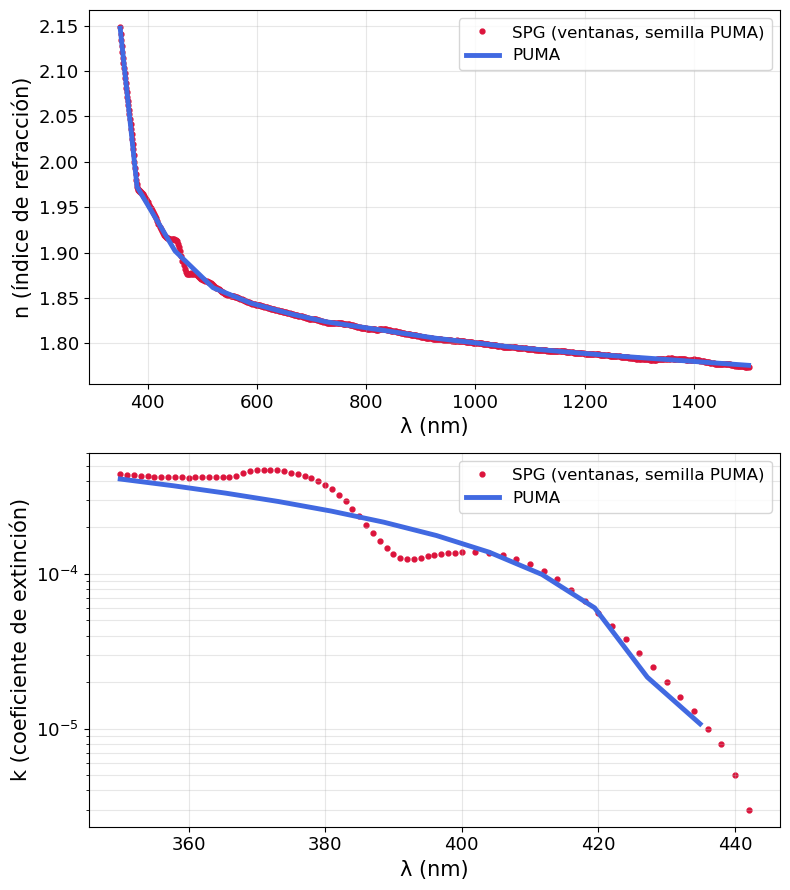

Guardado: C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\comparacion_PUMA_Fortran_S2.pdf
Guardado: C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\comparacion_PUMA_Fortran_S2.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ── CONFIGURACIÓN ─────────────────────────────────────────────────────────────
INF_PUMA    = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_result_PUMA\S2\WO3_S2_10sccm-inf_run3_150"
TABLA_FORTRAN = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\S2_tabla_final_nk_limpia.txt"

LABEL = "S2 — 10 sccm O₂"

# ── FUNCIONES ─────────────────────────────────────────────────────────────────
def leer_inf_puma(path):
    with open(path, "r") as f:
        lines = f.readlines()
    nk_start = None
    for i, line in enumerate(lines):
        if "lambda" in line and "kappa" in line:
            nk_start = i + 1
            break
    wl, n_arr, k_arr = [], [], []
    for line in lines[nk_start:]:
        parts = line.split()
        if len(parts) == 3:
            try:
                wl.append(float(parts[0])); n_arr.append(float(parts[1]))
                k_arr.append(float(parts[2]))
            except: break
        else: break
    return np.array(wl), np.array(n_arr), np.array(k_arr)

def leer_tabla_fortran(path):
    data = np.loadtxt(path)
    return data[:, 0], data[:, 1], data[:, 2]

# ── CARGAR DATOS ──────────────────────────────────────────────────────────────
wl_puma, n_puma, k_puma = leer_inf_puma(INF_PUMA)
wl_fort, n_fort, k_fort = leer_tabla_fortran(TABLA_FORTRAN)

print(f"PUMA:    {len(wl_puma)} puntos [{wl_puma.min():.0f}-{wl_puma.max():.0f}] nm")
print(f"Fortran: {len(wl_fort)} puntos [{wl_fort.min():.0f}-{wl_fort.max():.0f}] nm")

# ── FIGURA ────────────────────────────────────────────────────────────────────
FS_LABEL = 15   # etiquetas de ejes (n, k, λ)
FS_TICK  = 13   # numeros de los ticks
FS_LEG   = 12   # leyenda

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Panel n(λ)
# Submuestreo variable: todos los puntos por debajo de 400 nm (zona con más
# curvatura), 1 de cada 3 en el resto (zona ya suave)
mask_denso = wl_fort < 400
idx_denso  = np.where(mask_denso)[0]
idx_disperso = np.where(~mask_denso)[0][::2]
idx_spg = np.sort(np.concatenate([idx_denso, idx_disperso]))

axes[0].plot(wl_fort[idx_spg], n_fort[idx_spg], "o", color="crimson",
             markersize=3.5, zorder=1, label="SPG (ventanas, semilla PUMA)")
axes[0].plot(wl_puma, n_puma, color="royalblue", linewidth=3.5, zorder=2, label="PUMA")
axes[0].set_ylabel("n (índice de refracción)", fontsize=FS_LABEL)
axes[0].set_xlabel("λ (nm)", fontsize=FS_LABEL)
axes[0].tick_params(axis="both", labelsize=FS_TICK)
axes[0].legend(fontsize=FS_LEG)
axes[0].grid(True, alpha=0.3)

# Panel k(λ)
# Umbral: valores por debajo de ~1e-6 se consideran ruido numerico (k≈0)
UMBRAL_K = 2e-6
k_puma_plot = k_puma.copy()
k_puma_plot[k_puma_plot < UMBRAL_K] = np.nan
k_fort_plot = k_fort.copy()
k_fort_plot[k_fort_plot < UMBRAL_K] = np.nan

axes[1].plot(wl_fort[idx_spg], k_fort_plot[idx_spg], "o", color="crimson",
             markersize=3.5, zorder=1, label="SPG (ventanas, semilla PUMA)")
axes[1].plot(wl_puma, k_puma_plot, color="royalblue", linewidth=3.5, zorder=2, label="PUMA")
axes[1].set_ylabel("k (coeficiente de extinción)", fontsize=FS_LABEL)
axes[1].set_xlabel("λ (nm)", fontsize=FS_LABEL)
axes[1].tick_params(axis="both", labelsize=FS_TICK)
axes[1].set_yscale("log")
axes[1].legend(fontsize=FS_LEG)
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
out_pdf = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\comparacion_PUMA_Fortran_S2.pdf"
out_png = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\comparacion_PUMA_Fortran_S2.png"
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
plt.savefig(out_png, bbox_inches="tight", dpi=300)
plt.show()
print(f"Guardado: {out_pdf}")
print(f"Guardado: {out_png}")

In [20]:
import numpy as np
from scipy.interpolate import PchipInterpolator
import matplotlib
matplotlib.use("Agg")   # backend sin GUI — evita crashes en Jupyter/VSCode
import matplotlib.pyplot as plt

# ── CONFIGURACION ─────────────────────────────────────────────────────────────
TABLA_ENTRADA = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\S2_tabla_final_nk.txt"
TABLA_SALIDA  = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\S2_tabla_final_nk_limpia.txt"

# Region identificada manualmente a partir de los datos reales:
# de 459nm (n=1.916) a 468nm (n=1.872) hay una caida de 0.044 en 9nm,
# mucho mas empinada que el resto de la curva (~0.003 en 18nm en zonas vecinas)
LAM_EXCLUIR_MIN = 455.0
LAM_EXCLUIR_MAX = 472.0

# ── CARGAR DATOS ──────────────────────────────────────────────────────────────
data = np.loadtxt(TABLA_ENTRADA)
lam, n, k = data[:, 0], data[:, 1], data[:, 2]

mask_excluir = (lam >= LAM_EXCLUIR_MIN) & (lam <= LAM_EXCLUIR_MAX)
print(f"Puntos excluidos para re-interpolar: {mask_excluir.sum()} "
      f"(rango {LAM_EXCLUIR_MIN}-{LAM_EXCLUIR_MAX} nm)")

n_bueno   = n[~mask_excluir]
lam_bueno = lam[~mask_excluir]

interp_n = PchipInterpolator(lam_bueno, n_bueno)
n_limpio = n.copy()
n_limpio[mask_excluir] = interp_n(lam[mask_excluir])

k_limpio = k.copy()   # k ya estaba bien, no se toca

# ── GUARDAR TABLA LIMPIA ──────────────────────────────────────────────────────
with open(TABLA_SALIDA, "w") as f:
    for l, nn, kk in zip(lam, n_limpio, k_limpio):
        f.write(f"{l:.6f}   {nn:.6f}   {kk:.6f}\n")

print(f"Tabla limpia guardada en: {TABLA_SALIDA}")

# ── FIGURA DE VERIFICACION (guardada, no interactiva) ────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lam, n, color="lightcoral", linewidth=1.2, alpha=0.6, label="Original (con valle)")
ax.plot(lam, n_limpio, color="crimson", linewidth=2, label="Limpio (interpolado)")
ax.axvspan(LAM_EXCLUIR_MIN, LAM_EXCLUIR_MAX, alpha=0.15, color="gray",
           label="Region recortada")
ax.set_xlabel("λ (nm)", fontsize=11)
ax.set_ylabel("n", fontsize=11)
ax.set_title("Limpieza manual del valle en n(λ)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(400, 520)
plt.tight_layout()
out_fig = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\verificacion_limpieza_n.pdf"
plt.savefig(out_fig, dpi=200)
plt.close(fig)
print(f"Figura guardada en: {out_fig}")

Puntos excluidos para re-interpolar: 18 (rango 455.0-472.0 nm)
Tabla limpia guardada en: C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\S2_tabla_final_nk_limpia.txt
Figura guardada en: C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\verificacion_limpieza_n.pdf


PUMA:    175 puntos [350-1500] nm
Fortran: 1151 puntos [350-1500] nm


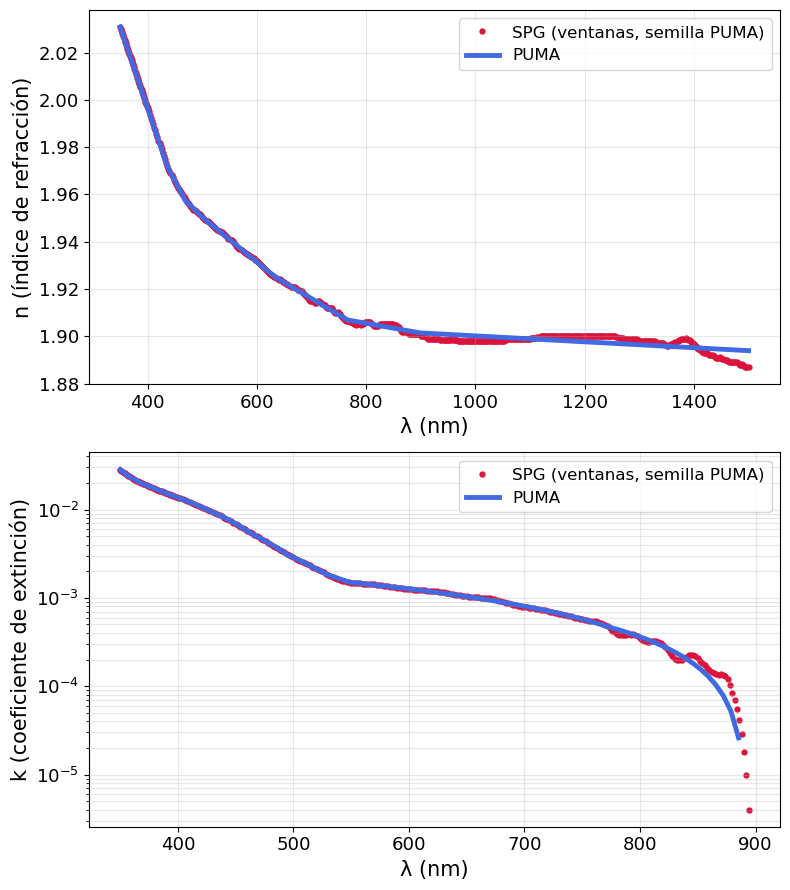

Guardado: C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\comparacion_PUMA_Fortran_S5.pdf
Guardado: C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\comparacion_PUMA_Fortran_S5.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ── CONFIGURACIÓN ─────────────────────────────────────────────────────────────
INF_PUMA    = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_result_PUMA\S5\WO3_S5_7sccm-inf_run3_175"
TABLA_FORTRAN = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\S5_tabla_final_nk.txt"

LABEL = "S5 — 7 sccm O₂"

# ── FUNCIONES ─────────────────────────────────────────────────────────────────
def leer_inf_puma(path):
    with open(path, "r") as f:
        lines = f.readlines()
    nk_start = None
    for i, line in enumerate(lines):
        if "lambda" in line and "kappa" in line:
            nk_start = i + 1
            break
    wl, n_arr, k_arr = [], [], []
    for line in lines[nk_start:]:
        parts = line.split()
        if len(parts) == 3:
            try:
                wl.append(float(parts[0])); n_arr.append(float(parts[1]))
                k_arr.append(float(parts[2]))
            except: break
        else: break
    return np.array(wl), np.array(n_arr), np.array(k_arr)

def leer_tabla_fortran(path):
    data = np.loadtxt(path)
    return data[:, 0], data[:, 1], data[:, 2]

# ── CARGAR DATOS ──────────────────────────────────────────────────────────────
wl_puma, n_puma, k_puma = leer_inf_puma(INF_PUMA)
wl_fort, n_fort, k_fort = leer_tabla_fortran(TABLA_FORTRAN)

print(f"PUMA:    {len(wl_puma)} puntos [{wl_puma.min():.0f}-{wl_puma.max():.0f}] nm")
print(f"Fortran: {len(wl_fort)} puntos [{wl_fort.min():.0f}-{wl_fort.max():.0f}] nm")

# ── FIGURA ────────────────────────────────────────────────────────────────────
FS_LABEL = 15   # etiquetas de ejes (n, k, λ)
FS_TICK  = 13   # numeros de los ticks
FS_LEG   = 12   # leyenda

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Panel n(λ)
# Submuestreo variable: todos los puntos por debajo de 400 nm (zona con más
# curvatura), 1 de cada 3 en el resto (zona ya suave)
mask_denso = wl_fort < 400
idx_denso  = np.where(mask_denso)[0]
idx_disperso = np.where(~mask_denso)[0][::2]
idx_spg = np.sort(np.concatenate([idx_denso, idx_disperso]))

axes[0].plot(wl_fort[idx_spg], n_fort[idx_spg], "o", color="crimson",
             markersize=3.5, zorder=1, label="SPG (ventanas, semilla PUMA)")
axes[0].plot(wl_puma, n_puma, color="royalblue", linewidth=3.5, zorder=2, label="PUMA")
axes[0].set_ylabel("n (índice de refracción)", fontsize=FS_LABEL)
axes[0].set_xlabel("λ (nm)", fontsize=FS_LABEL)
axes[0].tick_params(axis="both", labelsize=FS_TICK)
axes[0].legend(fontsize=FS_LEG)
axes[0].grid(True, alpha=0.3)

# Panel k(λ)
# Umbral: valores por debajo de ~1e-6 se consideran ruido numerico (k≈0)
UMBRAL_K = 2e-6
k_puma_plot = k_puma.copy()
k_puma_plot[k_puma_plot < UMBRAL_K] = np.nan
k_fort_plot = k_fort.copy()
k_fort_plot[k_fort_plot < UMBRAL_K] = np.nan

axes[1].plot(wl_fort[idx_spg], k_fort_plot[idx_spg], "o", color="crimson",
             markersize=3.5, zorder=1, label="SPG (ventanas, semilla PUMA)")
axes[1].plot(wl_puma, k_puma_plot, color="royalblue", linewidth=3.5, zorder=2, label="PUMA")
axes[1].set_ylabel("k (coeficiente de extinción)", fontsize=FS_LABEL)
axes[1].set_xlabel("λ (nm)", fontsize=FS_LABEL)
axes[1].tick_params(axis="both", labelsize=FS_TICK)
axes[1].set_yscale("log")
axes[1].legend(fontsize=FS_LEG)
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
out_pdf = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\comparacion_PUMA_Fortran_S5.pdf"
out_png = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\comparacion_PUMA_Fortran_S5.png"
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
plt.savefig(out_png, bbox_inches="tight", dpi=300)
plt.show()
print(f"Guardado: {out_pdf}")
print(f"Guardado: {out_png}")

S2 PUMA: 150 pts | S2 SPG (submuestreado): 601 pts
S5 PUMA: 175 pts | S5 SPG (submuestreado): 601 pts


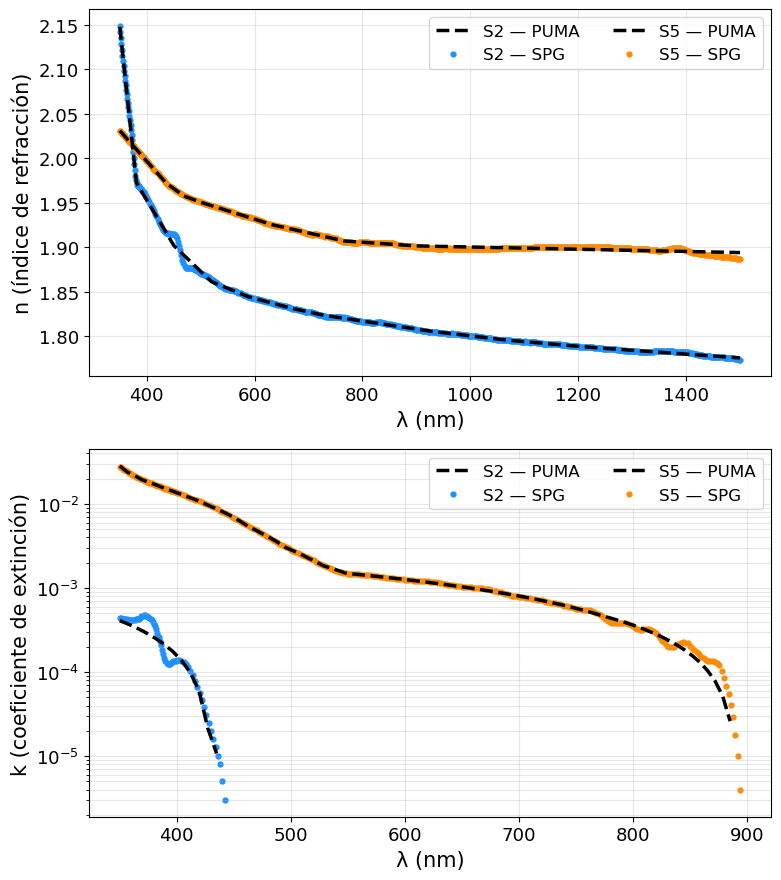

Guardado: C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\comparacion_PUMA_Fortran_S2vsS5.pdf
Guardado: C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\comparacion_PUMA_Fortran_S2vsS5.png


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ── CONFIGURACIÓN ─────────────────────────────────────────────────────────────
INF_PUMA_S2    = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_result_PUMA\S2\WO3_S2_10sccm-inf_run3_150"
TABLA_FORTRAN_S2 = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\S2_tabla_final_nk_limpia.txt"

INF_PUMA_S5    = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_result_PUMA\S5\WO3_S5_7sccm-inf_run3_175"
TABLA_FORTRAN_S5 = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\S5_tabla_final_nk.txt"

# Mismo codigo de colores que el resto del poster: azul = S2, naranja = S5.
# PUMA y SPG se distinguen por estilo (linea solida vs puntos), no por color.
COLOR_S2 = "dodgerblue"
COLOR_S5 = "darkorange"

# ── FUNCIONES ─────────────────────────────────────────────────────────────────
def leer_inf_puma(path):
    with open(path, "r") as f:
        lines = f.readlines()
    nk_start = None
    for i, line in enumerate(lines):
        if "lambda" in line and "kappa" in line:
            nk_start = i + 1
            break
    wl, n_arr, k_arr = [], [], []
    for line in lines[nk_start:]:
        parts = line.split()
        if len(parts) == 3:
            try:
                wl.append(float(parts[0])); n_arr.append(float(parts[1]))
                k_arr.append(float(parts[2]))
            except: break
        else: break
    return np.array(wl), np.array(n_arr), np.array(k_arr)

def leer_tabla_fortran(path):
    data = np.loadtxt(path)
    return data[:, 0], data[:, 1], data[:, 2]

def indices_submuestreo(wl_fort, umbral_denso=400, paso_disperso=2):
    mask_denso = wl_fort < umbral_denso
    idx_denso  = np.where(mask_denso)[0]
    idx_disperso = np.where(~mask_denso)[0][::paso_disperso]
    return np.sort(np.concatenate([idx_denso, idx_disperso]))

# ── CARGAR DATOS ──────────────────────────────────────────────────────────────
wl_puma_s2, n_puma_s2, k_puma_s2 = leer_inf_puma(INF_PUMA_S2)
wl_fort_s2, n_fort_s2, k_fort_s2 = leer_tabla_fortran(TABLA_FORTRAN_S2)
idx_s2 = indices_submuestreo(wl_fort_s2)

wl_puma_s5, n_puma_s5, k_puma_s5 = leer_inf_puma(INF_PUMA_S5)
wl_fort_s5, n_fort_s5, k_fort_s5 = leer_tabla_fortran(TABLA_FORTRAN_S5)
idx_s5 = indices_submuestreo(wl_fort_s5)

print(f"S2 PUMA: {len(wl_puma_s2)} pts | S2 SPG (submuestreado): {len(idx_s2)} pts")
print(f"S5 PUMA: {len(wl_puma_s5)} pts | S5 SPG (submuestreado): {len(idx_s5)} pts")

# ── FIGURA ────────────────────────────────────────────────────────────────────
FS_LABEL = 15
FS_TICK  = 13
FS_LEG   = 12

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Panel n(λ)
axes[0].plot(wl_puma_s2, n_puma_s2, color="black", linestyle="--", linewidth=2.5,
             zorder=2, label="S2 — PUMA")
axes[0].plot(wl_fort_s2[idx_s2], n_fort_s2[idx_s2], "o", color=COLOR_S2,
             markersize=3.5, zorder=1, label="S2 — SPG")
axes[0].plot(wl_puma_s5, n_puma_s5, color="black", linestyle="--", linewidth=2.5,
             zorder=2, label="S5 — PUMA")
axes[0].plot(wl_fort_s5[idx_s5], n_fort_s5[idx_s5], "o", color=COLOR_S5,
             markersize=3.5, zorder=1, label="S5 — SPG")
axes[0].set_ylabel("n (índice de refracción)", fontsize=FS_LABEL)
axes[0].set_xlabel("λ (nm)", fontsize=FS_LABEL)
axes[0].tick_params(axis="both", labelsize=FS_TICK)
axes[0].legend(fontsize=FS_LEG, ncol=2)
axes[0].grid(True, alpha=0.3)

# Panel k(λ)
# Umbral: valores por debajo de ~1e-6 se consideran ruido numerico (k≈0)
UMBRAL_K = 2e-6

k_puma_s2_plot = k_puma_s2.copy(); k_puma_s2_plot[k_puma_s2_plot < UMBRAL_K] = np.nan
k_fort_s2_plot = k_fort_s2.copy(); k_fort_s2_plot[k_fort_s2_plot < UMBRAL_K] = np.nan
k_puma_s5_plot = k_puma_s5.copy(); k_puma_s5_plot[k_puma_s5_plot < UMBRAL_K] = np.nan
k_fort_s5_plot = k_fort_s5.copy(); k_fort_s5_plot[k_fort_s5_plot < UMBRAL_K] = np.nan

axes[1].plot(wl_puma_s2, k_puma_s2_plot, color="black", linestyle="--", linewidth=2.5,
             zorder=2, label="S2 — PUMA")
axes[1].plot(wl_fort_s2[idx_s2], k_fort_s2_plot[idx_s2], "o", color=COLOR_S2,
             markersize=3.5, zorder=1, label="S2 — SPG")
axes[1].plot(wl_puma_s5, k_puma_s5_plot, color="black", linestyle="--", linewidth=2.5,
             zorder=2, label="S5 — PUMA")
axes[1].plot(wl_fort_s5[idx_s5], k_fort_s5_plot[idx_s5], "o", color=COLOR_S5,
             markersize=3.5, zorder=1, label="S5 — SPG")
axes[1].set_ylabel("k (coeficiente de extinción)", fontsize=FS_LABEL)
axes[1].set_xlabel("λ (nm)", fontsize=FS_LABEL)
axes[1].tick_params(axis="both", labelsize=FS_TICK)
axes[1].set_yscale("log")
axes[1].legend(fontsize=FS_LEG, ncol=2)
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
out_pdf = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\comparacion_PUMA_Fortran_S2vsS5.pdf"
out_png = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_fortran\comparacion_PUMA_Fortran_S2vsS5.png"
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
plt.savefig(out_png, bbox_inches="tight", dpi=300)
plt.show()
print(f"Guardado: {out_pdf}")
print(f"Guardado: {out_png}")